成功加载 38 个被试的索引
被试ID范围: 1 - 38
开始执行全面验证...

生成被试 1 的可视化检查...
被试ID: ODP_01_qhlazec


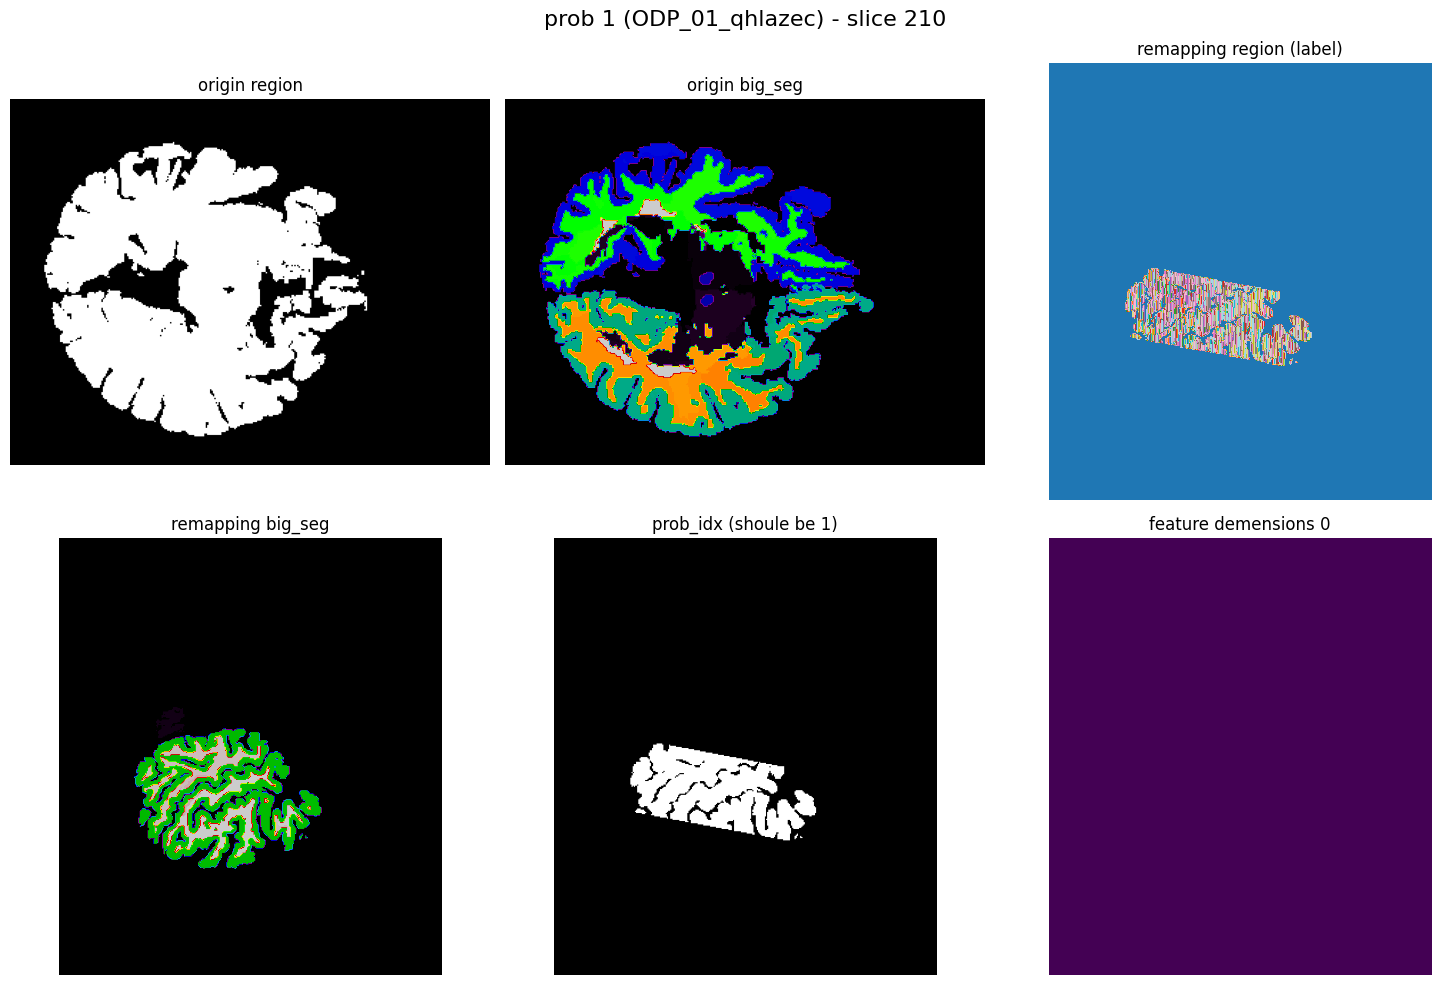

可视化已保存为: validation_ODP_01_qhlazec.png

验证被试 1
被试ID: ODP_01_qhlazec
原始文件: ODP_01_qhlazec.mat
3D文件: ODP_01_qhlazec_3d.mat
✅ 文件存在检查通过

加载数据...

1. 验证基本维度
  data形状: (384, 336, 256, 351) - ❌
  region形状: (384, 336, 256) - ❌
  prob_idx形状: (384, 336, 256) - ❌
  big_seg形状: (384, 336, 256) - ❌

2. 验证big_seg复制
  ❌ big_seg不匹配
    不同的体素: 1/33030144 (0.00%)

3. 验证prob_idx
  ✅ prob_idx正确: 所有有效体素值为 1

4. 验证multidim_data重映射
  验证multidim_data重映射...


/tmp/ipykernel_29827/1032461444.py:278: DeprecationWarning: elementwise comparison failed; this will raise an error in the future.
  diff = np.sum(original_data['big_seg'] != remapped_data['big_seg'])


: 

In [1]:
import numpy as np
import h5py
import json
import os
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm

class DatasetValidator:
    """全面验证3D重映射数据的正确性"""
    
    def __init__(self, json_path, original_dir, remapped_dir):
        """
        初始化验证器
        
        Parameters:
        - json_path: dataset_index.json的路径
        - original_dir: 原始1D数据目录
        - remapped_dir: 重映射3D数据目录
        """
        self.json_path = json_path
        self.original_dir = Path(original_dir)
        self.remapped_dir = Path(remapped_dir)
        
        # 加载索引
        with open(json_path, 'r') as f:
            data = json.load(f)
        
        # 判断JSON格式并相应处理
        if isinstance(data, dict):
            # 如果是字典格式，直接使用
            self.dataset_index = data
        elif isinstance(data, list):
            # 如果是列表格式，转换为字典
            self.dataset_index = {}
            for item in data:
                prob_idx = item['prob_idx']
                self.dataset_index[str(prob_idx)] = item
        else:
            raise ValueError(f"Unexpected JSON format: {type(data)}")
        
        # 确保所有键都是字符串
        self.dataset_index = {str(k): v for k, v in self.dataset_index.items()}
        
        self.validation_results = {}
        
        # 打印数据集信息
        print(f"成功加载 {len(self.dataset_index)} 个被试的索引")
        print(f"被试ID范围: {min(map(int, self.dataset_index.keys()))} - {max(map(int, self.dataset_index.keys()))}")

        
    def load_mat_h5(self, path):
        """正确加载MATLAB HDF5格式的MAT文件"""
        data = {}
        with h5py.File(path, "r") as f:
            for k in f.keys():
                if not k.startswith("#"):
                    v = f[k][()]
                    if v.ndim > 1:
                        v = v.T  # 关键：转置多维数组
                    data[k] = v
        return data
    
    def save_mat_h5(self, path, data_dict):
        """保存为MATLAB兼容的HDF5格式"""
        with h5py.File(path, 'w') as f:
            for key, value in data_dict.items():
                if value.ndim > 1:
                    # 保存前转置回MATLAB格式（列优先）
                    value = value.T
                f.create_dataset(key, data=value, compression="gzip")
        
    def revert_reshape_f_order(self, array, region):
        """使用Fortran顺序将1D数组重构回3D体积"""
        if array.ndim == 1:
            array = array[:, np.newaxis]
       
        num_features = array.shape[1]
        big_img = np.zeros((*region.shape, num_features), dtype=array.dtype)
        big_img = big_img.reshape(-1, array.shape[1], order='F')
       
        bool_mask = region.flatten(order='F').astype(bool)
        big_img[bool_mask] = array
       
        big_img = big_img.reshape((*region.shape, num_features), order='F')
        big_img = big_img.squeeze()
       
        return big_img
    
    def extract_1d_from_3d(self, volume_3d, region_mask):
        """
        从3D体积提取1D数据（逆向操作）
        
        Parameters:
        - volume_3d: 3D或4D数组
        - region_mask: 3D布尔掩膜
        
        Returns:
        - array_1d: 提取的1D或2D数组
        """
        if volume_3d.ndim == 3:
            volume_3d = volume_3d[..., np.newaxis]
        
        # 使用Fortran顺序展平
        volume_flat = volume_3d.reshape(-1, volume_3d.shape[-1], order='F')
        mask_flat = region_mask.flatten(order='F').astype(bool)
        
        # 提取有效体素
        array_1d = volume_flat[mask_flat]
        
        if array_1d.shape[1] == 1:
            array_1d = array_1d.squeeze()
        
        return array_1d
    
    def validate_single_subject(self, prob_idx):
        """验证单个被试的数据"""
        print(f"\n{'='*60}")
        print(f"验证被试 {prob_idx}")
        print(f"{'='*60}")
        
        results = {
            'prob_idx': prob_idx,
            'tests': {}
        }
        
        # 获取文件路径
        subject_info = self.dataset_index[str(prob_idx)]
        original_filename = subject_info['filename']  # 修改：从字典中获取filename
        original_path = self.original_dir / original_filename
        remapped_filename = original_filename.replace('.mat', '_3d.mat')
        remapped_path = self.remapped_dir / remapped_filename
        
        # 打印被试信息
        print(f"被试ID: {subject_info['subject_id']}")
        print(f"原始文件: {original_filename}")
        print(f"3D文件: {remapped_filename}")
        
        if not original_path.exists():
            print(f"❌ 原始文件不存在: {original_path}")
            results['tests']['file_exists'] = False
            return results
        
        if not remapped_path.exists():
            print(f"❌ 重映射文件不存在: {remapped_path}")
            results['tests']['file_exists'] = False
            return results
        
        results['tests']['file_exists'] = True
        print(f"✅ 文件存在检查通过")
        
        # 加载数据
        print("\n加载数据...")
        original_data = self.load_mat_h5(original_path)
        remapped_data = self.load_mat_h5(remapped_path)
        
        # 1. 验证基本维度
        print("\n1. 验证基本维度")
        results['tests']['dimensions'] = self.validate_dimensions(
            original_data, remapped_data
        )
        
        # 2. 验证big_seg复制
        print("\n2. 验证big_seg复制")
        results['tests']['big_seg'] = self.validate_big_seg(
            original_data, remapped_data
        )
        
        # 3. 验证prob_idx
        print("\n3. 验证prob_idx")
        results['tests']['prob_idx'] = self.validate_prob_idx(
            remapped_data, prob_idx
        )
        
        # 4. 验证multidim_data重映射
        print("\n4. 验证multidim_data重映射")
        results['tests']['multidim_data'] = self.validate_multidim_data(
            original_data, remapped_data
        )
        
        # 5. 验证seg_one_hot到region的转换
        print("\n5. 验证seg_one_hot到region的转换")
        results['tests']['region_labels'] = self.validate_region_labels(
            original_data, remapped_data
        )
        
        # 6. 验证数据完整性（逆向还原）
        print("\n6. 验证数据完整性（逆向还原）")
        results['tests']['data_integrity'] = self.validate_data_integrity(
            original_data, remapped_data
        )
        
        # 7. 验证数值范围和统计特性
        print("\n7. 验证数值范围和统计特性")
        results['tests']['statistics'] = self.validate_statistics(
            original_data, remapped_data
        )
        
        # 总结
        all_passed = all(
            v for k, v in results['tests'].items() 
            if isinstance(v, bool)
        )
        
        if all_passed:
            print(f"\n✅ 被试 {prob_idx} ({subject_info['subject_id']}) 所有验证通过！")
        else:
            print(f"\n⚠️ 被试 {prob_idx} ({subject_info['subject_id']}) 部分验证失败")
            failed_tests = [k for k, v in results['tests'].items() 
                        if isinstance(v, bool) and not v]
            print(f"失败的测试: {failed_tests}")
        
        return results
    
    def validate_dimensions(self, original_data, remapped_data):
        """验证维度是否正确"""
        checks = {}
        
        # 检查3D形状
        expected_shape = original_data['region'].shape  # (384, 336, 256)
        
        # data应该是4D: (384, 336, 256, 351)
        if 'data' in remapped_data:
            data_shape = remapped_data['data'].shape
            # 检查是否需要转置（如果维度顺序错误）
            if data_shape == (256, 336, 384, 351):
                print(f"  ⚠️ data需要转置: {data_shape}")
                checks['data_shape'] = False
            else:
                checks['data_shape'] = (
                    data_shape[:3] == expected_shape and 
                    data_shape[3] == 351
                )
            print(f"  data形状: {data_shape} - {'✅' if checks['data_shape'] else '❌'}")
        
        # region应该是3D: (384, 336, 256)
        if 'region' in remapped_data:
            region_shape = remapped_data['region'].shape
            if region_shape == (256, 336, 384):
                print(f"  ⚠️ region需要转置: {region_shape}")
                checks['region_shape'] = False
            else:
                checks['region_shape'] = region_shape == expected_shape
            print(f"  region形状: {region_shape} - {'✅' if checks['region_shape'] else '❌'}")
        
        # prob_idx应该是3D: (384, 336, 256)
        if 'prob_idx' in remapped_data:
            prob_idx_shape = remapped_data['prob_idx'].shape
            if prob_idx_shape == (256, 336, 384):
                print(f"  ⚠️ prob_idx需要转置: {prob_idx_shape}")
                checks['prob_idx_shape'] = False
            else:
                checks['prob_idx_shape'] = prob_idx_shape == expected_shape
            print(f"  prob_idx形状: {prob_idx_shape} - {'✅' if checks['prob_idx_shape'] else '❌'}")
        
        # big_seg应该保持原形状
        if 'big_seg' in remapped_data:
            big_seg_shape = remapped_data['big_seg'].shape
            checks['big_seg_shape'] = big_seg_shape == original_data['big_seg'].shape
            print(f"  big_seg形状: {big_seg_shape} - {'✅' if checks['big_seg_shape'] else '❌'}")
        
        return all(checks.values())


    
    def validate_big_seg(self, original_data, remapped_data):
        """验证big_seg是否正确复制"""
        if 'big_seg' not in remapped_data:
            print("  ❌ big_seg不存在于重映射数据中")
            return False
        
        match = np.array_equal(original_data['big_seg'], remapped_data['big_seg'])
        if match:
            print(f"  ✅ big_seg完全匹配")
        else:
            print(f"  ❌ big_seg不匹配")
            # 详细分析差异
            diff = np.sum(original_data['big_seg'] != remapped_data['big_seg'])
            total = original_data['big_seg'].size
            print(f"    不同的体素: {diff}/{total} ({100*diff/total:.2f}%)")
        
        return match
    
    def validate_prob_idx(self, remapped_data, expected_idx):
        """验证prob_idx是否正确"""
        if 'prob_idx' not in remapped_data:
            print("  ❌ prob_idx不存在")
            return False
        
        prob_idx_3d = remapped_data['prob_idx']
        region_mask = remapped_data['region'] > 0
        
        # 检查有效区域内的值
        unique_vals = np.unique(prob_idx_3d[region_mask])
        
        if len(unique_vals) == 1 and unique_vals[0] == expected_idx:
            print(f"  ✅ prob_idx正确: 所有有效体素值为 {expected_idx}")
            return True
        else:
            print(f"  ❌ prob_idx错误: 期望 {expected_idx}, 实际值: {unique_vals}")
            return False
    
    def validate_multidim_data(self, original_data, remapped_data):
        """验证multidim_data的3D重映射"""
        print("  验证multidim_data重映射...")
        
        original_features = original_data['multidim_data']  # (n_voxels, 351)
        remapped_3d = remapped_data['data']  # (384, 336, 256, 351)
        region = original_data['region'].astype(bool)
        
        # 从3D提取回1D
        extracted_1d = self.extract_1d_from_3d(remapped_3d, region)
        
        # 比较形状
        if original_features.shape != extracted_1d.shape:
            print(f"    ❌ 形状不匹配: 原始 {original_features.shape} vs 提取 {extracted_1d.shape}")
            return False
        
        # 比较数值
        tolerance = 1e-6
        max_diff = np.max(np.abs(original_features - extracted_1d))
        mean_diff = np.mean(np.abs(original_features - extracted_1d))
        
        if max_diff < tolerance:
            print(f"    ✅ 数值完全匹配 (最大差异: {max_diff:.2e})")
            return True
        else:
            print(f"    ⚠️ 数值有差异: 最大 {max_diff:.2e}, 平均 {mean_diff:.2e}")
            
            # 随机采样几个特征维度进行详细比较
            sample_dims = np.random.choice(351, min(5, 351), replace=False)
            for dim in sample_dims:
                orig_vals = original_features[:, dim]
                extr_vals = extracted_1d[:, dim]
                corr = np.corrcoef(orig_vals, extr_vals)[0, 1]
                print(f"      维度 {dim}: 相关系数 = {corr:.6f}")
            
            return max_diff < 0.01  # 允许小的数值误差
    

    def validate_region_labels(self, original_data, remapped_data):
        """验证seg_one_hot到region的转换"""
        print("  验证标签转换...")
        
        original_onehot = original_data['seg_one_hot']  # (102, n_voxels)
        remapped_labels_3d = remapped_data['region']  # 应该是 (384, 336, 256)
        region_mask = original_data['region'].astype(bool)
        
        # 检查维度是否匹配
        if remapped_labels_3d.shape != region_mask.shape:
            print(f"    ❌ 3D标签形状与region不匹配: {remapped_labels_3d.shape} vs {region_mask.shape}")
            return False
        
        # 从one-hot获取标签（注意：one-hot是(102, n_voxels)格式）
        original_labels = np.argmax(original_onehot, axis=0)  # shape: (n_voxels,)
        
        # 从3D提取1D标签
        extracted_labels = self.extract_1d_from_3d(
            remapped_labels_3d[..., np.newaxis], 
            region_mask
        ).squeeze()
        
        # 比较
        if len(original_labels) != len(extracted_labels):
            print(f"    ❌ 长度不匹配: {len(original_labels)} vs {len(extracted_labels)}")
            return False
        
        matches = np.sum(original_labels == extracted_labels)
        total = len(original_labels)
        match_rate = 100 * matches / total
        
        if match_rate > 99.99:
            print(f"    ✅ 标签匹配率: {match_rate:.2f}%")
            return True
        else:
            print(f"    ⚠️ 标签匹配率: {match_rate:.2f}%")
            
            # 分析不匹配的标签
            mismatches = original_labels != extracted_labels
            if np.sum(mismatches) > 0:
                mismatch_indices = np.where(mismatches)[0][:10]
                for idx in mismatch_indices:
                    print(f"      索引 {idx}: 原始={original_labels[idx]}, 提取={extracted_labels[idx]}")
            
            return match_rate > 95
    

    
    def validate_data_integrity(self, original_data, remapped_data):
        """通过完整的逆向还原验证数据完整性"""
        print("  执行完整性验证...")
        
        region = original_data['region'].astype(bool)
        checks = {}
        
        # 1. 重新构建3D然后还原，验证是否一致
        print("    测试重构-还原循环...")
        
        # 对multidim_data进行循环测试
        original_features = original_data['multidim_data']
        
        # 选择几个随机特征维度进行测试
        test_dims = np.random.choice(351, min(10, 351), replace=False)
        
        for dim in test_dims:
            feature_1d = original_features[:, dim]
            
            # 重构到3D
            feature_3d = self.revert_reshape_f_order(feature_1d, region)
            
            # 还原回1D
            feature_1d_restored = self.extract_1d_from_3d(
                feature_3d[..., np.newaxis], 
                region
            ).squeeze()
            
            # 验证
            if np.allclose(feature_1d, feature_1d_restored, rtol=1e-5):
                checks[f'dim_{dim}'] = True
            else:
                checks[f'dim_{dim}'] = False
                max_diff = np.max(np.abs(feature_1d - feature_1d_restored))
                print(f"      维度 {dim} 循环测试失败: 最大差异 {max_diff:.2e}")
        
        # 2. 验证非零体素数量一致性
        n_voxels_original = np.sum(region)
        n_voxels_3d = np.sum(remapped_data['region'] > 0)
        checks['voxel_count'] = (n_voxels_original == n_voxels_3d)
        
        if checks['voxel_count']:
            print(f"    ✅ 有效体素数量一致: {n_voxels_original}")
        else:
            print(f"    ❌ 有效体素数量不一致: 原始={n_voxels_original}, 3D={n_voxels_3d}")
        
        return all(checks.values())
    
    def validate_statistics(self, original_data, remapped_data):
        """验证数据的统计特性"""
        print("  验证统计特性...")
        
        checks = {}
        
        # 1. 验证特征数据的统计特性
        original_features = original_data['multidim_data']  # (n_voxels, 351)
        remapped_3d = remapped_data['data']  # 应该是 (384, 336, 256, 351)
        region = original_data['region'].astype(bool)  # (384, 336, 256)
        
        # 检查维度是否匹配
        if remapped_3d.shape[:3] != region.shape:
            print(f"    ❌ 3D数据形状与region不匹配: {remapped_3d.shape[:3]} vs {region.shape}")
            return False
        
        # 从3D提取1D来比较
        extracted_features = self.extract_1d_from_3d(remapped_3d, region)
        
        # 比较均值和标准差
        for i in range(min(5, 351)):
            orig_mean = np.mean(original_features[:, i])
            orig_std = np.std(original_features[:, i])
            
            extr_mean = np.mean(extracted_features[:, i])
            extr_std = np.std(extracted_features[:, i])
            
            mean_diff = abs(orig_mean - extr_mean)
            std_diff = abs(orig_std - extr_std)
            
            checks[f'feature_{i}_mean'] = mean_diff < 1e-4
            checks[f'feature_{i}_std'] = std_diff < 1e-4
            
            if mean_diff > 1e-4 or std_diff > 1e-4:
                print(f"      特征 {i}: 均值差={mean_diff:.2e}, 标准差差={std_diff:.2e}")
        
        # 2. 验证标签分布
        original_labels = np.argmax(original_data['seg_one_hot'], axis=0)
        
        # 从3D提取标签
        remapped_labels_3d = remapped_data['region']
        if remapped_labels_3d.shape == region.shape:
            extracted_labels = self.extract_1d_from_3d(
                remapped_labels_3d[..., np.newaxis],
                region
            ).squeeze()
            
            orig_unique, orig_counts = np.unique(original_labels, return_counts=True)
            extr_unique, extr_counts = np.unique(extracted_labels, return_counts=True)
            
            if len(orig_unique) == len(extr_unique):
                label_match = True
                for label in orig_unique:
                    if label in extr_unique:
                        orig_count = orig_counts[orig_unique == label][0]
                        extr_count = extr_counts[extr_unique == label][0]
                        if orig_count != extr_count:
                            label_match = False
                            print(f"      标签 {label}: 原始计数={orig_count}, 提取计数={extr_count}")
                checks['label_distribution'] = label_match
            else:
                checks['label_distribution'] = False
                print(f"      标签数量不一致: 原始={len(orig_unique)}, 提取={len(extr_unique)}")
        else:
            checks['label_distribution'] = False
            print(f"      无法验证标签分布：维度不匹配")
        
        overall = all(checks.values())
        if overall:
            print("    ✅ 统计特性验证通过")
        else:
            print("    ⚠️ 部分统计特性有差异")
        
        return overall

    
    def validate_all(self):
        """验证所有被试"""
        print("\n" + "="*70)
        print("开始全面验证所有被试数据")
        print("="*70)
        
        all_results = []
        failed_subjects = []
        
        for prob_idx in range(1, 39):  # 1-38
            try:
                result = self.validate_single_subject(prob_idx)
                all_results.append(result)
                
                # 检查是否有失败的测试
                if result['tests']:
                    all_passed = all(
                        v for k, v in result['tests'].items() 
                        if isinstance(v, bool)
                    )
                    if not all_passed:
                        failed_subjects.append(prob_idx)
                        
            except Exception as e:
                print(f"\n❌ 被试 {prob_idx} 验证过程出错: {str(e)}")
                failed_subjects.append(prob_idx)
                all_results.append({
                    'prob_idx': prob_idx,
                    'error': str(e)
                })
        
        # 生成总结报告
        self.generate_report(all_results, failed_subjects)
        
        return all_results
    
    def generate_report(self, all_results, failed_subjects):
        """生成验证报告"""
        print("\n" + "="*70)
        print("验证报告总结")
        print("="*70)
        
        total_subjects = len(all_results)
        passed_subjects = total_subjects - len(failed_subjects)
        
        print(f"\n总体结果:")
        print(f"  总被试数: {total_subjects}")
        print(f"  通过验证: {passed_subjects}")
        print(f"  失败验证: {len(failed_subjects)}")
        
        if failed_subjects:
            print(f"\n失败的被试:")
            for prob_idx in failed_subjects:
                subject_info = self.dataset_index[str(prob_idx)]
                print(f"  - {prob_idx}: {subject_info['subject_id']}")
            
            # 分析失败原因
            failure_reasons = {}
            for result in all_results:
                if result['prob_idx'] in failed_subjects and 'tests' in result:
                    for test_name, test_result in result['tests'].items():
                        if isinstance(test_result, bool) and not test_result:
                            if test_name not in failure_reasons:
                                failure_reasons[test_name] = []
                            failure_reasons[test_name].append(result['prob_idx'])
            
            if failure_reasons:
                print("\n失败原因分析:")
                for reason, subjects in failure_reasons.items():
                    print(f"  {reason}:")
                    for prob_idx in subjects:
                        subject_info = self.dataset_index[str(prob_idx)]
                        print(f"    - {prob_idx}: {subject_info['subject_id']}")
        else:
            print("\n🎉 所有被试验证通过！")
        
        # 添加被试信息到结果
        for result in all_results:
            prob_idx = result['prob_idx']
            subject_info = self.dataset_index[str(prob_idx)]
            result['subject_id'] = subject_info['subject_id']
            result['filename'] = subject_info['filename']
        
        # 保存详细报告
        report_path = Path("validation_report.json")
        with open(report_path, 'w') as f:
            json.dump({
                'summary': {
                    'total': total_subjects,
                    'passed': passed_subjects,
                    'failed': len(failed_subjects),
                    'failed_subjects': failed_subjects
                },
                'details': all_results
            }, f, indent=2, default=str)
        
        print(f"\n详细报告已保存至: {report_path}")


    
    def spot_check_visualization(self, prob_idx, slice_idx=None):
        """可视化检查特定被试的数据"""
        print(f"\n生成被试 {prob_idx} 的可视化检查...")
        
        # 加载数据
        subject_info = self.dataset_index[str(prob_idx)]
        original_filename = subject_info['filename']  # 修改：从字典中获取filename
        original_path = self.original_dir / original_filename
        remapped_filename = original_filename.replace('.mat', '_3d.mat')
        remapped_path = self.remapped_dir / remapped_filename
        
        print(f"被试ID: {subject_info['subject_id']}")
        
        original_data = self.load_mat_h5(original_path)
        remapped_data = self.load_mat_h5(remapped_path)
        
        if slice_idx is None:
            slice_idx = original_data['region'].shape[2] // 2
        
        # 创建比较图
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.suptitle(f"prob {prob_idx} ({subject_info['subject_id']}) - slice {slice_idx}", fontsize=16)
        
        # 原始region
        axes[0, 0].imshow(original_data['region'][:, :, slice_idx], cmap='gray')
        axes[0, 0].set_title('origin region')
        axes[0, 0].axis('off')
        
        # 原始big_seg
        axes[0, 1].imshow(original_data['big_seg'][:, :, slice_idx], cmap='nipy_spectral')
        axes[0, 1].set_title('origin big_seg')
        axes[0, 1].axis('off')
        
        # 重映射的region (标签)
        axes[0, 2].imshow(remapped_data['region'][:, :, slice_idx], cmap='tab20')
        axes[0, 2].set_title('remapping region (label)')
        axes[0, 2].axis('off')
        
        # 重映射的big_seg
        axes[1, 0].imshow(remapped_data['big_seg'][:, :, slice_idx], cmap='nipy_spectral')
        axes[1, 0].set_title('remapping big_seg')
        axes[1, 0].axis('off')
        
        # prob_idx
        axes[1, 1].imshow(remapped_data['prob_idx'][:, :, slice_idx], cmap='gray')
        axes[1, 1].set_title(f'prob_idx (shoule be {prob_idx})')
        axes[1, 1].axis('off')
        
        # 一个特征维度
        feature_dim = 0
        axes[1, 2].imshow(remapped_data['data'][:, :, slice_idx, feature_dim], cmap='viridis')
        axes[1, 2].set_title(f'feature demensions {feature_dim}')
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        
        # 使用subject_id作为文件名
        output_filename = f"validation_{subject_info['subject_id']}.png"
        plt.savefig(output_filename, dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"可视化已保存为: {output_filename}")


# 使用示例
if __name__ == "__main__":
    # 设置路径
    json_path = "/home/jannik/Documents/mri_mat_onehot/1D/dataset_index.json"
    original_dir = "/home/jannik/Documents/mri_mat_onehot/1D"
    remapped_dir = "/home/jannik/Documents/mri_mat_onehot/3D"
    
    # 创建验证器
    validator = DatasetValidator(json_path, original_dir, remapped_dir)
    
    # 执行全面验证
    print("开始执行全面验证...")
    # results = validator.validate_all()
    
    # 可选：对特定被试进行可视化检查
    validator.spot_check_visualization(prob_idx=1,slice_idx=210)
    
    # 可选：单独验证某个被试
    result = validator.validate_single_subject(prob_idx=1)